In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

In [ ]:
mail=pd.read_csv("/content/spam.csv", encoding='latin-1')

In [ ]:
mail.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
mail.shape

(5572, 5)

In [ ]:
mail = mail[['v1','v2']]
mail.columns = ['label','message']
mail.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
mail['label'] = mail['label'].map({
    'ham':0,
    'spam':1
})
mail.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
mail.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
mail['label'].value_counts()

,count
label,
0,4825
1,747


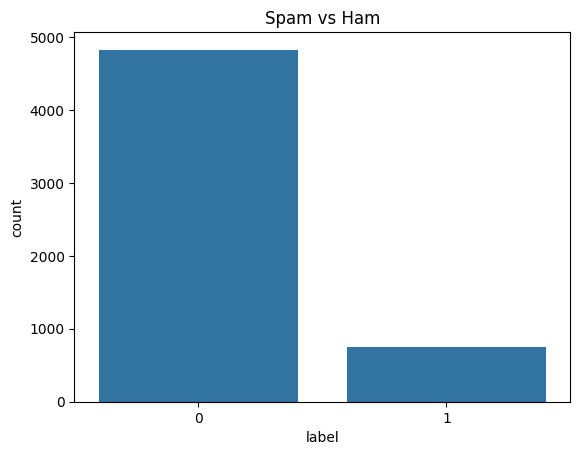

In [ ]:
sns.countplot(x=mail['label'])

plt.title("Spam vs Ham")
plt.show()

In [ ]:
X = mail['message']
y = mail['label']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.7
)


X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
X_train_tfidf.shape

(4457, 7472)

In [ ]:
model = MultinomialNB()


model.fit(
    X_train_tfidf,
    y_train
)

MultinomialNB()

In [ ]:
y_pred = model.predict(
    X_test_tfidf
)

In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:",accuracy)

Accuracy: 0.9668161434977578


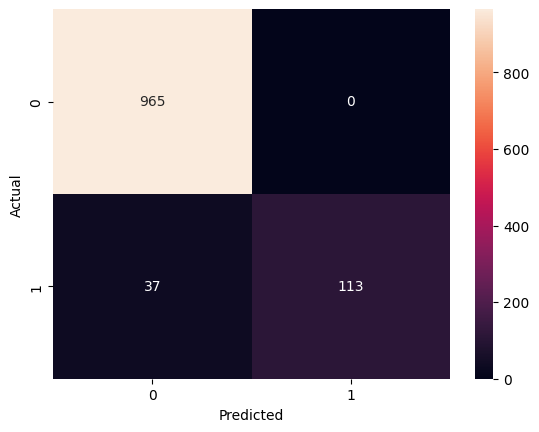

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)


sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print(
classification_report(
    y_test,
    y_pred
)
)

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.75      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115



In [ ]:
emails = [
    "Congratulations you won a free prize",
    "Hey, are we meeting tomorrow?"
]


email_vector = vectorizer.transform(emails)


prediction = model.predict(email_vector)


for mail,result in zip(emails,prediction):

    if result==1:
        print(mail,"--> SPAM")
    else:
        print(mail,"--> NOT SPAM")

Congratulations you won a free prize --> SPAM
Hey, are we meeting tomorrow? --> NOT SPAM


In [ ]:
joblib.dump(
    model,
    "spam_detector.pkl"
)


joblib.dump(
    vectorizer,
    "vectorizer.pkl"
)

['vectorizer.pkl']

In [1]:
from google.colab import files

files.download("spam_detector.pkl")
files.download("vectorizer.pkl")

FileNotFoundError: Cannot find file: spam_detector.pkl